In [19]:
from keras.preprocessing.sequence import pad_sequences
from keras.layers import LSTM, Dense, Embedding, Input
from keras.models import Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
import pandas as pd
from numpy import asarray
from numpy import zeros
import re
import matplotlib.pyplot as plt
from keras.utils import plot_model

import warnings
warnings.filterwarnings("ignore")

In [21]:
!unzip /kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/train.csv.zip
!unzip /kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/test.csv.zip
!unzip /kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/test_labels.csv.zip
!unzip /kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/sample_submission.csv.zip

Archive:  /kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/train.csv.zip
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C
Archive:  /kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/test.csv.zip
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C
Archive:  /kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/test_labels.csv.zip
replace test_labels.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C
Archive:  /kaggle/input/competitions/jigsaw-toxic-comment-classification-challenge/sample_submission.csv.zip
replace sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [22]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
test_labels = pd.read_csv("test_labels.csv")
sample_submission = pd.read_csv("sample_submission.csv")

In [23]:
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [24]:
test.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [25]:
test_labels.head()

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,-1,-1,-1,-1,-1,-1
1,0000247867823ef7,-1,-1,-1,-1,-1,-1
2,00013b17ad220c46,-1,-1,-1,-1,-1,-1
3,00017563c3f7919a,-1,-1,-1,-1,-1,-1
4,00017695ad8997eb,-1,-1,-1,-1,-1,-1


In [26]:
sample_submission.head()

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,0.5,0.5,0.5,0.5,0.5,0.5
1,0000247867823ef7,0.5,0.5,0.5,0.5,0.5,0.5
2,00013b17ad220c46,0.5,0.5,0.5,0.5,0.5,0.5
3,00017563c3f7919a,0.5,0.5,0.5,0.5,0.5,0.5
4,00017695ad8997eb,0.5,0.5,0.5,0.5,0.5,0.5


In [27]:
toxic_comments = train.copy()
filter = toxic_comments["comment_text"] != ""
toxic_comments = toxic_comments[filter]
toxic_comments = toxic_comments.dropna()

print(toxic_comments["comment_text"][168])

print("Toxic:" + str(toxic_comments["toxic"][168]))
print("Severe_toxic:" + str(toxic_comments["severe_toxic"][168]))
print("Obscene:" + str(toxic_comments["obscene"][168]))
print("Threat:" + str(toxic_comments["threat"][168]))
print("Insult:" + str(toxic_comments["insult"][168]))
print("Identity_hate:" + str(toxic_comments["identity_hate"][168]))

You should be fired, you're a moronic wimp who is too lazy to do research. It makes me sick that people like you exist in this world.
Toxic:1
Severe_toxic:0
Obscene:0
Threat:0
Insult:1
Identity_hate:0


<Axes: >

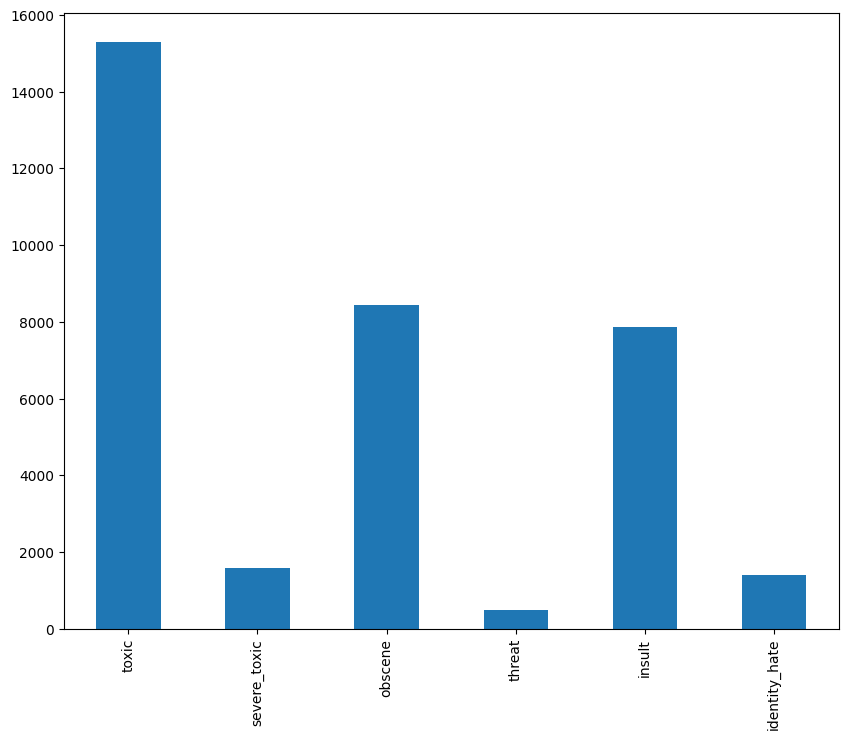

In [28]:
toxic_comments_labels = toxic_comments[["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]]
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 10
fig_size[1] = 8
plt.rcParams["figure.figsize"] = fig_size
toxic_comments_labels.sum(axis=0).plot.bar()

In [29]:
def preprocess_text(sen):
    sentence = re.sub('[^a-zA-Z]', ' ', sen)
    sentence = re.sub(r'\s+[a-zA-Z]\s+', ' ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence)
    return sentence

X = []
sentences = list(toxic_comments["comment_text"])
for sen in sentences:
    X.append(preprocess_text(sen))
y = toxic_comments_labels.values

In [30]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X)

X_train_seq = tokenizer.texts_to_sequences(X)

vocab_size = len(tokenizer.word_index) + 1
maxlen = 200

X_train = pad_sequences(X_train_seq, padding='post', maxlen=maxlen)

In [31]:
embeddings_dictionary = dict()

glove_file = open('glove.6B.100d.txt', encoding="utf8")

for line in glove_file:
    records = line.split()
    word = records[0]
    vector_dimensions = asarray(records[1:], dtype='float32')
    embeddings_dictionary[word] = vector_dimensions
glove_file.close()

embedding_matrix = zeros((vocab_size, 100))
for word, index in tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

In [32]:
deep_inputs = Input(shape=(maxlen,))
embedding_layer = Embedding(vocab_size, 100, weights=[embedding_matrix], trainable=False)(deep_inputs)
LSTM_Layer_1 = LSTM(128)(embedding_layer)
dense_layer_1 = Dense(6, activation='sigmoid')(LSTM_Layer_1)
model = Model(inputs=deep_inputs, outputs=dense_layer_1)

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 200, 100)       │    16,881,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,999,722 (64.85 MB)

 Trainable params: 118,022 (461.02 KB)

 Non-trainable params: 16,881,700 (64.40 MB)

None


In [33]:
history = model.fit(X_train, y, batch_size = 128, epochs = 5, verbose = 1, validation_split = 0.2)

Epoch 1/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 437s 436ms/step - acc: 0.9786 - loss: 0.1444 - val_acc: 0.9937 - val_loss: 0.1479
Epoch 2/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 434s 434ms/step - acc: 0.9933 - loss: 0.0832 - val_acc: 0.9940 - val_loss: 0.0643
Epoch 3/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 436s 437ms/step - acc: 0.9942 - loss: 0.0602 - val_acc: 0.9941 - val_loss: 0.0587
Epoch 4/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 434s 435ms/step - acc: 0.9942 - loss: 0.0560 - val_acc: 0.9941 - val_loss: 0.0554
Epoch 5/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 448s 449ms/step - acc: 0.9942 - loss: 0.0539 - val_acc: 0.9941 - val_loss: 0.0544


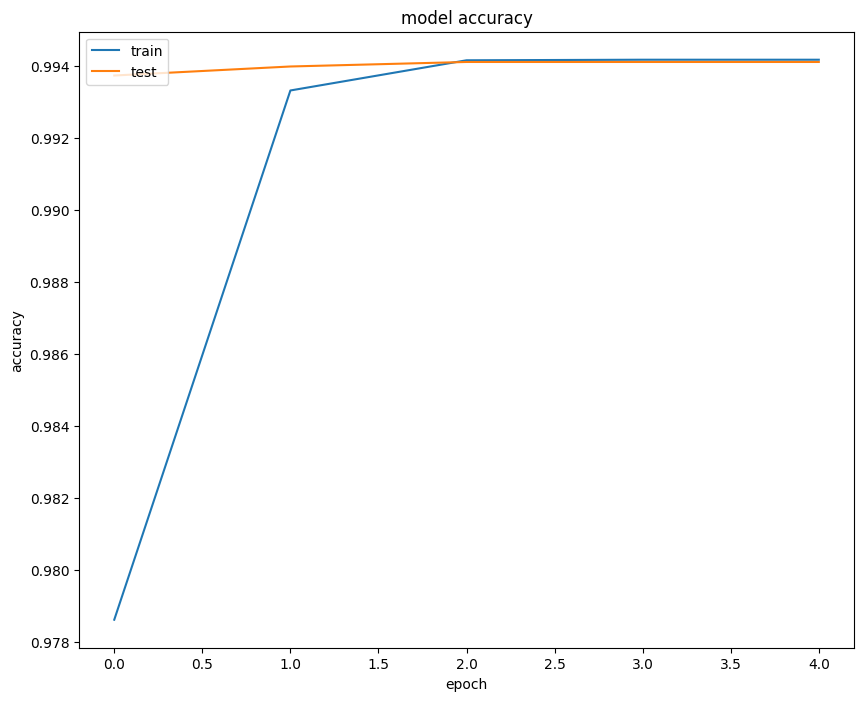

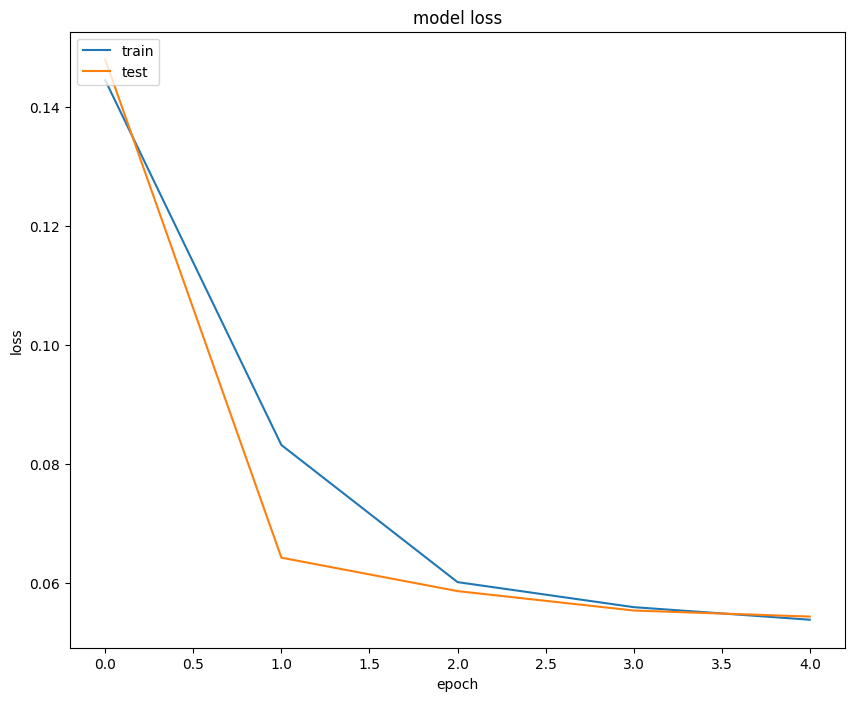

In [34]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [35]:
test_sentences = list(test["comment_text"])
X_submission = [preprocess_text(sen) for sen in test_sentences]

X_submission = tokenizer.texts_to_sequences(X_submission)
X_submission = pad_sequences(X_submission, padding='post', maxlen=maxlen)

y_pred_submission = model.predict(X_submission, batch_size=128, verbose=1)

submission = sample_submission.copy()
submission[["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]] = y_pred_submission

1197/1197 ━━━━━━━━━━━━━━━━━━━━ 206s 172ms/step


In [37]:
submission.to_csv("submission.csv", index=False)
print("Submission file 'submission.csv' created successfully!")
submission.head()

Submission file 'submission.csv' created successfully!


,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,0.987534,0.183012,0.940466,0.052274,0.810855,0.166269
1,0000247867823ef7,0.002830,0.000018,0.000558,0.000043,0.000654,0.000114
2,00013b17ad220c46,0.007940,0.000055,0.001474,0.000117,0.001807,0.000293
3,00017563c3f7919a,0.002026,0.000013,0.000408,0.000031,0.000479,0.000084
4,00017695ad8997eb,0.043949,0.000339,0.007375,0.000632,0.009796,0.001483
